In [39]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Load TCS Data
# -----------------------------
df = yf.download("TCS.NS", start="2023-01-01", end="2026-03-29")

df = df[['Close']]

# -----------------------------
# 2. Feature Engineering
# -----------------------------
df['MA10'] = df['Close'].rolling(10).mean()
df['MA20'] = df['Close'].rolling(20).mean()
df['Return'] = df['Close'].pct_change()

df = df.dropna()

features = ['MA10', 'MA20', 'Return']
X = df[features]
y = df['Close']

# -----------------------------
# 3. Train-Test Split (IMPORTANT)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, test_size=0.2
)

# -----------------------------
# 4. Train Model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# 5. Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# 6. Evaluation Metrics
# -----------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
accuracy = 100 - mape

print("📊 Model Evaluation (TCS):")
print(f"MAE       : {mae:.2f}")
print(f"RMSE      : {rmse:.2f}")
print(f"MAPE      : {mape:.2f}%")
print(f"Accuracy  : {accuracy:.2f}%")

# -----------------------------
# 7. Comparison Table
# -----------------------------
comparison = pd.DataFrame({
    'Actual Price': y_test.values.flatten(),
    'Predicted Price': y_pred.flatten()
})

comparison['Error'] = comparison['Actual Price'] - comparison['Predicted Price']

print("\n📈 Last 10 Predictions vs Actual:")
print(comparison.tail(10))

# -----------------------------
# 8. Live Prediction vs Last Actual
# -----------------------------
last_actual = df['Close'].iloc[-1].item() # Extract scalar value
last_features = df[features].iloc[-1].values.reshape(1, -1)

predicted_next = model.predict(last_features)[0].item()

error = abs(predicted_next - last_actual)
error_pct = (error / last_actual) * 100

print("\n🔴 Live Comparison:")
print(f"Last Actual Price : {last_actual:.2f}")
print(f"Predicted Price   : {predicted_next:.2f}")
print(f"Error             : {error:.2f}")
print(f"Error %           : {error_pct:.2f}%")
print(f"Accuracy %        : {100 - error_pct:.2f}%")

/tmp/ipykernel_3523/2429355944.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("TCS.NS", start="2023-01-01", end="2026-03-29")
[*********************100%***********************]  1 of 1 completed

📊 Model Evaluation (TCS):
MAE       : 40.26
RMSE      : 52.91
MAPE      : 1.38%
Accuracy  : 98.62%

📈 Last 10 Predictions vs Actual:
     Actual Price  Predicted Price      Error
146   2410.500000      2471.767308 -61.267308
147   2409.199951      2484.729076 -75.529124
148   2391.699951      2438.798663 -47.098711
149   2440.800049      2511.271021 -70.470972
150   2356.000000      2313.077546  42.922454
151   2390.600098      2450.952521 -60.352423
152   2383.800049      2381.969534   1.830514
153   2398.800049      2400.484066  -1.684017
154   2377.399902      2344.467965  32.931938
155   2389.800049      2386.700405   3.099644

🔴 Live Comparison:
Last Actual Price : 2389.80
Predicted Price   : 2386.70
Error             : 3.10
Error %           : 0.13%
Accuracy %        : 99.87%


Forecasted prices for next 2 days:
Day 1: 2454.43
Day 2: 2446.76


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


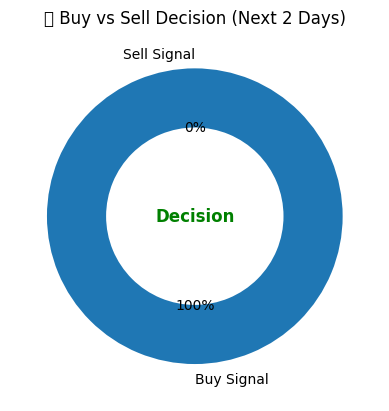

In [49]:
# Forecast next 2 days
future_prices_2_days = agent.forecast_prices(num_days=2)

print("Forecasted prices for next 2 days:")
for i, price in enumerate(future_prices_2_days):
    print(f"Day {i+1}: {price[0]:.2f}")
import matplotlib.pyplot as plt

# -----------------------------
# 1. Get last actual price
# -----------------------------
last_actual = agent.df['Close_TCS.NS'].iloc[-1].item() # Extract scalar value

# -----------------------------
# 2. Analyze forecast
# -----------------------------
buy_count = 0
sell_count = 0

for price in future_prices_2_days:
    predicted_price = price[0]

    if predicted_price > last_actual:
        buy_count += 1
    else:
        sell_count += 1

# -----------------------------
# 3. Prepare data
# -----------------------------
labels = ['Buy Signal', 'Sell Signal']
sizes = [buy_count, sell_count]

# -----------------------------
# 4. Create Donut Chart
# -----------------------------
fig, ax = plt.subplots()

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)  # This makes it DONUT
)

# Center text
ax.text(0, 0, 'Decision', ha='center', va='center', fontsize=12, fontweight='bold',color="green")

ax.set_title("📊 Buy vs Sell Decision (Next 2 Days)")

plt.show()